# Interpretabilidad: entender qué hace un modelo de caja negra

> Cómo averiguar qué variables mueven las predicciones de un modelo que no se puede leer (un bosque, un *boosting*, una red): importancia por permutación, gráficos de dependencia parcial, valores de Shapley (explicación de una predicción concreta) y destilación a un modelo simple; qué responde cada técnica y en qué se equivoca.
>
> **Requisitos previos:** [Bagging y Random Forest](10-bagging-y-random-forest.ipynb) · [Árboles de decisión](08-arboles-decision.ipynb) · **Relacionado:** [Selección de atributos](03-seleccion-atributos.ipynb) · [Boosting](11-boosting.ipynb) · [Sesgo algorítmico](13-sesgo-algoritmico.ipynb)

## 1. Idea clave

Los modelos que mejor predicen con datos tabulares (bosques, *boosting*, redes) son **cajas negras** (*black box*): no se pueden leer como una regresión lineal o un árbol pequeño. La interpretabilidad (o **explicabilidad**, *explainability*) reúne técnicas para responder, **después** de entrenar, a dos preguntas: ¿qué variables importan al modelo **en general** (explicación global)? y ¿por qué ha dado **esta** predicción concreta (explicación local)?

Se usa para depurar el modelo (¿se apoya en una variable que no debería?), para auditarlo ([sesgo](13-sesgo-algoritmico.ipynb)), para comunicarlo a quien decide y para sugerir hipótesis sobre los datos. Hay un límite que conviene tener presente desde el principio: **estas técnicas explican el modelo, no el mundo**. Una variable importante para el modelo no tiene por qué ser una causa de nada.

## 2. Conceptos importantes

### 2.1. Interpretable, explicable y caja negra

- Un modelo **interpretable** se entiende directamente: regresión lineal y logística (los coeficientes), árbol pequeño (el recorrido hasta la hoja).
- Una **caja negra** es demasiado compleja o es propietaria.
- Un modelo es **explicable** si, siendo caja negra, se le puede aplicar una técnica que lo interprete *a posteriori*. Las técnicas de este notebook son de ese tipo y no necesitan mirar dentro del modelo (**agnósticas al modelo**, *model-agnostic*): solo le piden predicciones.

Cuando el error de predicción es caro (medicina, justicia), hay quien defiende usar directamente un modelo interpretable aunque pierda algo de exactitud, en vez de explicar uno opaco. Es una decisión de diseño que se debe tomar antes de elegir el modelo.

### 2.2. Importancia por impureza (la que trae el modelo)

En un bosque o un árbol, `feature_importances_` suma, para cada variable, cuánto reducen la impureza los nodos que dividen por ella (ponderado por el número de ejemplos del nodo) y se normaliza para que sume 1. Es gratis, pero tiene dos defectos: se calcula **con los datos de entrenamiento** (un modelo sobreajustado reparte importancia a variables que solo explican ruido) y **favorece** variables continuas o con muchas categorías, que ofrecen más puntos de corte.

### 2.3. Importancia por permutación

Se mide cuánto **empeora** la métrica del modelo cuando se destruye la información de una variable. Dado un modelo $f$, una métrica $s$ (donde mayor es mejor, p. ej. $R^2$), un conjunto de evaluación $(X,y)$ y $X^{(j,k)}$ la matriz con la columna $j$ barajada aleatoriamente (repetición $k$ de $K$):

$$
I_j = s(f, X, y) - \frac{1}{K}\sum_{k=1}^{K} s\big(f, X^{(j,k)}, y\big).
$$

Barajar rompe la relación de la variable con el objetivo y con las demás. Se calcula con el modelo ya entrenado, con cualquier métrica y, si se hace sobre datos **no vistos**, mide lo que la variable aporta a la capacidad de generalizar. Su problema son las variables **correlacionadas**: si dos columnas llevan la misma información, barajar una no hace daño porque el modelo se apoya en la otra, y las dos parecen poco importantes.

### 2.4. Dependencia parcial y curvas ICE

La importancia dice *cuánto* pesa una variable, pero no *cómo* afecta. La **dependencia parcial** (*partial dependence*, PD) promedia la predicción sobre todos los ejemplos fijando la variable $j$ en un valor $z$:

$$
\mathrm{PD}_j(z) = \frac{1}{n}\sum_{i=1}^{n} f\big(z,\, x_{i,\setminus j}\big),
$$

donde $x_{i,\setminus j}$ son las demás variables del ejemplo $i$. Las curvas **ICE** (*individual conditional expectation*) dibujan una curva por ejemplo en vez del promedio: si todas son paralelas, el promedio es representativo; si se cruzan, hay interacciones que el promedio esconde.

### 2.5. Valores de Shapley: explicar una predicción

Vienen de la teoría de juegos cooperativos: varios jugadores colaboran para conseguir un premio, ¿cuánto corresponde a cada uno? Aquí los jugadores son las $p$ variables y el "premio" es la predicción para un ejemplo $x$ **menos** la predicción media de referencia. El valor de Shapley de la variable $j$ es su contribución marginal promediada sobre todos los órdenes en que podría "incorporarse":

$$
\phi_j(x)=\sum_{S\subseteq F\setminus\{j\}}\frac{|S|!\,(p-|S|-1)!}{p!}\Big[v(S\cup\{j\})-v(S)\Big],
\qquad
v(S)=\mathbb{E}_{b}\big[f(x_S,\,b_{\bar S})\big],
$$

con $F$ el conjunto de variables, $v(S)$ la predicción esperada cuando las variables de $S$ toman el valor de $x$ y el resto se toma de un **conjunto de referencia** (*background*) de ejemplos $b$. Propiedades clave:

- **Eficiencia**: $\sum_j\phi_j(x)=f(x)-v(\emptyset)$; las contribuciones suman exactamente la diferencia entre la predicción y la media de referencia.
- **Simetría** (dos variables equivalentes reciben lo mismo) y **jugador nulo** (una variable que no cambia nada recibe 0).
- **Aditividad**: para un conjunto de modelos (un bosque), el valor de Shapley es la media de los de cada árbol.

El coste es el defecto: hay $2^p$ coaliciones. Con pocas variables se puede calcular exacto (lo haremos); con muchas se aproxima (la librería `shap` implementa algoritmos rápidos, p. ej. para árboles). Promediando $|\phi_j|$ sobre muchos ejemplos se obtiene una importancia **global** coherente con las explicaciones locales. Se usan mucho para medir cuánto contribuye un atributo protegido a una decisión ([sesgo](13-sesgo-algoritmico.ipynb)).

### 2.6. Destilación y modelos sustitutos

La **destilación de conocimiento** (*knowledge distillation*) entrena un modelo simple e interpretable (el **estudiante**, p. ej. un árbol pequeño) para imitar las predicciones del complejo (el **profesor**) en vez de las etiquetas reales. Si el estudiante reproduce fielmente al profesor, su explicación sirve para el profesor. Se mide con la **fidelidad**: el $R^2$ (o la concordancia) entre las predicciones de estudiante y profesor. Hay una crítica razonable: si un modelo simple fuera tan bueno, ¿por qué no usarlo directamente? Lo comprobamos en 3.6.

### 2.7. Influencia de las observaciones

Otra pregunta es qué **ejemplos de entrenamiento** han determinado el modelo: se quita un ejemplo, se reentrena y se mide cuánto cambian los parámetros o las predicciones (distancia de Cook, DFBETA). Reentrenar por cada ejemplo es caro en modelos complejos y existen aproximaciones (funciones de influencia). No lo implementamos aquí.

## 3. Código

Usamos **California housing** (20 640 distritos censales de California, censo de 1990; objetivo: valor mediano de la vivienda en unidades de 100 000 dólares, con un tope en 5,0). Las variables son medias por distrito: `MedInc` (ingreso mediano), `HouseAge`, `AveRooms`, `AveBedrms`, `Population`, `AveOccup` (ocupantes por vivienda), `Latitude` y `Longitude`. Es la versión que distribuye scikit-learn, ya preparada para regresión.

Añadimos una columna `ruido` (aleatoria, sin relación con el objetivo) como **variable de control**: una buena técnica de importancia tiene que darle importancia cercana a cero. El modelo es un `RandomForestRegressor` ([bosques](10-bagging-y-random-forest.ipynb)).

In [1]:
import warnings
from math import factorial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="IProgress not found")   # aviso de tqdm (barras de progreso) al importar shap
import shap
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text

### 3.1. Datos y modelo

In [2]:
datos = fetch_california_housing(as_frame=True)
rng = np.random.default_rng(42)
X = datos.data.assign(ruido=rng.normal(size=len(datos.data)))
y = datos.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bosque = RandomForestRegressor(n_estimators=100, min_samples_leaf=3, random_state=42, n_jobs=-1).fit(X_train, y_train)
print(X.shape)
print(f"R² en entrenamiento: {r2_score(y_train, bosque.predict(X_train)):.3f}   R² en test: {r2_score(y_test, bosque.predict(X_test)):.3f}")

(20640, 9)
R² en entrenamiento: 0.940   R² en test: 0.802


### 3.2. Importancia por impureza y por permutación

Comparamos tres medidas: la importancia por impureza (con los datos de entrenamiento), la de permutación calculada sobre el **entrenamiento** y la de permutación sobre el **test**. La permutación mide la caída de $R^2$ al barajar la columna (5 repeticiones).

In [3]:
perm_train = permutation_importance(bosque, X_train, y_train, n_repeats=5, random_state=42, n_jobs=-1)
perm_test = permutation_importance(bosque, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
importancias = pd.DataFrame({
    "impureza (train)": bosque.feature_importances_,
    "permutación (train)": perm_train.importances_mean,
    "permutación (test)": perm_test.importances_mean,
    "desviación (test)": perm_test.importances_std,
}, index=X.columns).sort_values("permutación (test)", ascending=False)
importancias.round(3)

,impureza (train),permutación (train),permutación (test),desviación (test)
MedInc,0.545,0.927,0.822,0.017
Latitude,0.083,0.391,0.371,0.009
Longitude,0.083,0.305,0.262,0.005
AveOccup,0.136,0.288,0.204,0.006
HouseAge,0.051,0.109,0.070,0.003
AveRooms,0.041,0.063,0.023,0.001
AveBedrms,0.023,0.029,0.008,0.001
Population,0.024,0.027,0.006,0.001
ruido,0.015,0.014,0.000,0.001


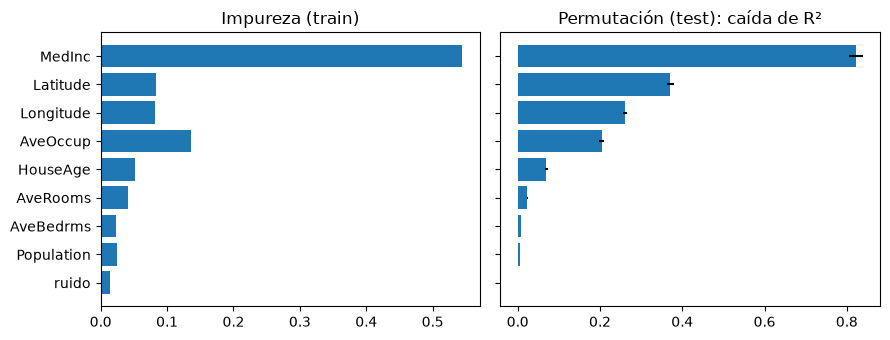

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
orden = importancias.index[::-1]
axes[0].barh(orden, importancias.loc[orden, "impureza (train)"])
axes[0].set_title("Impureza (train)")
axes[1].barh(orden, importancias.loc[orden, "permutación (test)"], xerr=importancias.loc[orden, "desviación (test)"])
axes[1].set_title("Permutación (test): caída de R²")
plt.tight_layout()
plt.show()

`MedInc` domina con las tres medidas, y la ubicación (`Latitude`, `Longitude`) y la ocupación (`AveOccup`) vienen después. La variable de control `ruido` recibe un 1,5 % de la importancia por impureza (es el bosque aprovechando ruido de entrenamiento para dividir), y su permutación sobre el **entrenamiento** también sale positiva (0,014): el modelo ha memorizado algo de ese ruido y barajarlo le hace daño en entrenamiento. Sobre el **test** su importancia es 0,000: el ruido no ayuda a generalizar. Por eso la permutación sobre datos no vistos es más honesta. Las barras de error (desviación de las 5 repeticiones) son pequeñas frente a las diferencias entre variables principales.

#### Variables correlacionadas
Añadimos a entrenamiento y test una copia casi idéntica de `MedInc` (con un poco de ruido), reentrenamos y volvemos a medir.

In [5]:
rng_copia = np.random.default_rng(0)
X_train_c = X_train.assign(MedInc_copia=X_train["MedInc"] + rng_copia.normal(scale=0.1, size=len(X_train)))
X_test_c = X_test.assign(MedInc_copia=X_test["MedInc"] + rng_copia.normal(scale=0.1, size=len(X_test)))
bosque_c = RandomForestRegressor(n_estimators=100, min_samples_leaf=3, random_state=42, n_jobs=-1).fit(X_train_c, y_train)
perm_c = permutation_importance(bosque_c, X_test_c, y_test, n_repeats=5, random_state=42, n_jobs=-1)
pd.DataFrame({"sin copia": importancias["permutación (test)"], "con copia de MedInc": pd.Series(perm_c.importances_mean, index=X_train_c.columns)}).loc[
    ["MedInc", "MedInc_copia", "Latitude", "Longitude", "AveOccup"]].round(3)

# Barajando las dos columnas de ingreso a la vez (con la misma permutación)
X_juntas = X_test_c.copy()
orden_juntas = np.random.default_rng(42).permutation(len(X_juntas))
X_juntas[["MedInc", "MedInc_copia"]] = X_test_c[["MedInc", "MedInc_copia"]].to_numpy()[orden_juntas]
print(f"Caída de R² barajando juntas MedInc y su copia: {r2_score(y_test, bosque_c.predict(X_test_c)) - r2_score(y_test, bosque_c.predict(X_juntas)):.3f}")

Caída de R² barajando juntas MedInc y su copia: 0.801


`MedInc` baja de 0,82 a 0,58 y la copia recibe 0,04, aunque el modelo es esencialmente el mismo: la información de ingreso está repartida entre dos columnas y barajar solo una deja la otra casi intacta. Con variables correlacionadas, **la permutación de una columna subestima su importancia**. Barajar las dos columnas a la vez (última línea de la celda) recupera la importancia del ingreso, porque ya no queda ninguna con esa información. En la práctica se permutan juntas las columnas correlacionadas o se agrupan.

### 3.3. Dependencia parcial y curvas ICE

Mostramos, para tres variables, el promedio (PD, línea gruesa) y 50 curvas individuales (ICE) sobre una muestra del test.

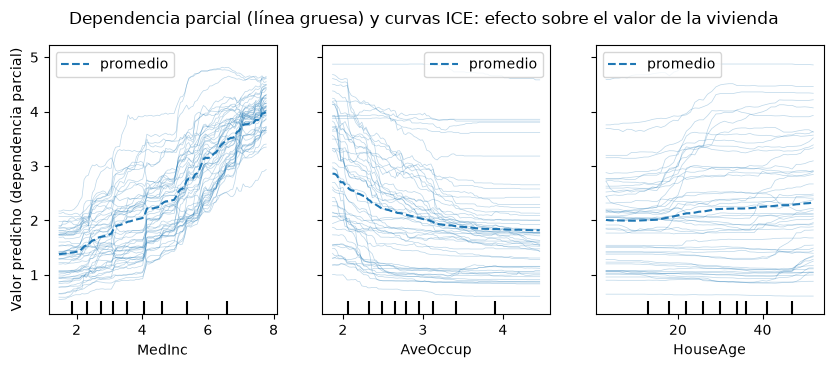

In [6]:
pd_display = PartialDependenceDisplay.from_estimator(bosque, X_test.sample(500, random_state=42), ["MedInc", "AveOccup", "HouseAge"],
                                                    kind="both", subsample=50, random_state=42, n_jobs=-1)
pd_display.figure_.set_size_inches(10, 3.5)
pd_display.figure_.suptitle("Dependencia parcial (línea gruesa) y curvas ICE: efecto sobre el valor de la vivienda")
pd_display.axes_[0, 0].set_ylabel("Valor predicho (dependencia parcial)")
for ax in pd_display.axes_.ravel():
    ax.get_legend().get_texts()[0].set_text("promedio")
plt.show()

El valor predicho sube de forma casi continua con el ingreso mediano (`MedInc`), de ≈ 1,4 a ≈ 4,0. Las curvas ICE de `MedInc` son bastante paralelas, así que el promedio es representativo. En `AveOccup` (ocupantes por vivienda) el promedio cae de ≈ 2,9 a ≈ 1,8 entre 2 y 3,5 ocupantes y luego se queda plano, pero las curvas individuales cuentan otra historia: unas caen mucho y muchas otras son casi horizontales. Es una **interacción** (el efecto de la ocupación depende de otras variables, p. ej. la ubicación) que el promedio esconde. `HouseAge` casi no mueve la predicción.

### 3.4. Valores de Shapley, calculados a mano

Con 9 variables hay $2^9=512$ coaliciones y podemos implementar la definición de 2.5 directamente. Para cada coalición construimos copias del conjunto de referencia (50 ejemplos del entrenamiento) en las que las variables de la coalición toman el valor de $x$, y promediamos las predicciones del bosque.

In [7]:
def valores_shapley(modelo, x, fondo):
    columnas = list(x.index)
    p = len(columnas)
    mascaras = np.arange(2 ** p)                      # cada número es una coalición (bit j = variable j)
    bloques = []
    for m in mascaras:
        z = fondo.copy()
        for j, c in enumerate(columnas):
            if (m >> j) & 1:
                z[c] = x[c]
        bloques.append(z)
    v = modelo.predict(pd.concat(bloques, ignore_index=True)).reshape(2 ** p, len(fondo)).mean(axis=1)
    phi = np.zeros(p)
    for j in range(p):
        for m in mascaras:
            if not (m >> j) & 1:
                s = bin(m).count("1")
                peso = factorial(s) * factorial(p - s - 1) / factorial(p)
                phi[j] += peso * (v[m | (1 << j)] - v[m])
    return pd.Series(phi, index=columnas), v[0], v[-1]   # v[0]: media de referencia; v[-1]: predicción para x

fondo = X_train.sample(50, random_state=42)
x0 = X_test.iloc[0]
phi, base, pred = valores_shapley(bosque, x0, fondo)
print(f"Media de referencia: {base:.3f}   Predicción para x0: {pred:.3f}   Valor real: {y_test.iloc[0]:.3f}")
print(f"Suma de los valores de Shapley: {phi.sum():.3f}  (debe ser predicción - media = {pred - base:.3f})")
print(phi.round(2).sort_values().to_string())

Media de referencia: 2.233   Predicción para x0: 0.488   Valor real: 0.477
Suma de los valores de Shapley: -1.745  (debe ser predicción - media = -1.745)
MedInc       -0.94
Latitude     -0.36
AveOccup     -0.21
Longitude    -0.19
AveRooms     -0.05
HouseAge     -0.00
AveBedrms     0.00
Population    0.00
ruido        -0.00


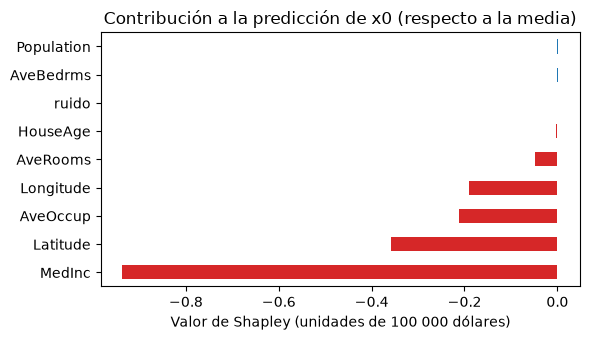

,MedInc,AveOccup,Latitude,Longitude
x0,1.68,3.88,36.06,-119.01


In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
phi.sort_values().plot.barh(ax=ax, color=["tab:red" if v < 0 else "tab:blue" for v in phi.sort_values()])
ax.set_title("Contribución a la predicción de x0 (respecto a la media)")
ax.set_xlabel("Valor de Shapley (unidades de 100 000 dólares)")
plt.tight_layout()
plt.show()
x0[["MedInc", "AveOccup", "Latitude", "Longitude"]].round(2).to_frame("x0").T

La predicción para este distrito es unas 1,7 unidades **inferior** a la media de referencia, y las contribuciones suman exactamente esa diferencia (propiedad de eficiencia). Casi todo viene de `MedInc` (−0,94: ingreso bajo para California), seguido de la ubicación (`Latitude` −0,36 y `Longitude` −0,19) y de `AveOccup` (−0,21); `ruido`, `AveBedrms` y `HouseAge` están en torno a 0, como deben. Calculamos ahora la importancia **global** de Shapley: la media de $|\phi_j|$ sobre 60 ejemplos del test, y la comparamos con la de permutación.

In [9]:
phis = pd.DataFrame([valores_shapley(bosque, X_test.iloc[i], fondo)[0] for i in range(60)])
comparacion = pd.DataFrame({"media |Shapley| (60 ejemplos)": phis.abs().mean(),
                            "permutación (test)": importancias["permutación (test)"]}).sort_values("media |Shapley| (60 ejemplos)", ascending=False)
comparacion.round(3)

,media |Shapley| (60 ejemplos),permutación (test)
MedInc,0.487,0.822
Latitude,0.315,0.371
Longitude,0.270,0.262
AveOccup,0.211,0.204
HouseAge,0.086,0.070
AveRooms,0.045,0.023
AveBedrms,0.022,0.008
Population,0.019,0.006
ruido,0.007,0.000


El orden es prácticamente el mismo (`MedInc`, `Latitude`, `Longitude`, `AveOccup`, `HouseAge`…) y `ruido` queda en ≈ 0 en ambas. Las dos miden cosas distintas (la caída de $R^2$ frente a la contribución media a la predicción) y por eso sus escalas no son comparables, pero cuando coinciden en el orden la conclusión es más fiable. Con 60 ejemplos y 50 de referencia el cálculo exacto tarda del orden de diez segundos: con más variables o más datos hace falta un algoritmo más eficiente, como el de la librería `shap` (3.5).

### 3.5. Con la librería `shap`

`shap.TreeExplainer` calcula los valores de Shapley de un modelo de árboles con un algoritmo que **no recorre las $2^p$ coaliciones**. Con `feature_perturbation="interventional"` y el mismo conjunto de referencia, la definición es la misma que implementamos a mano, así que debe dar lo mismo. Lo comprobamos con $x_0$ y calculamos las contribuciones de 500 ejemplos del test (a mano tardaríamos varios minutos).

Máxima diferencia con el cálculo a mano para x0: 4.37e-04


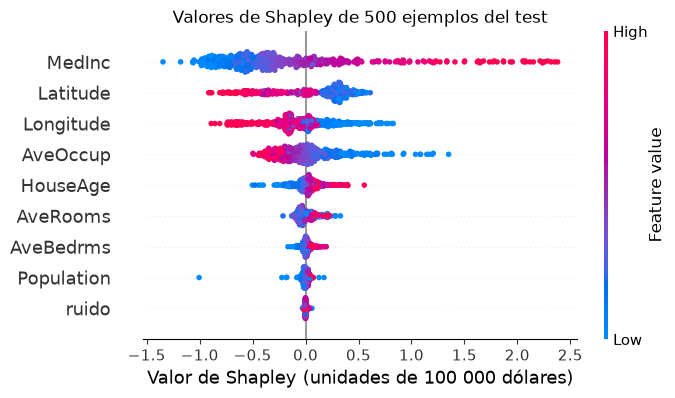

In [10]:
explicador = shap.TreeExplainer(bosque, data=fondo, feature_perturbation="interventional")
shap_x0 = explicador(X_test.iloc[:1])
print(f"Máxima diferencia con el cálculo a mano para x0: {np.abs(shap_x0.values[0] - phi.to_numpy()).max():.2e}")

shap_500 = explicador(X_test.iloc[:500])
shap.plots.beeswarm(shap_500, show=False)
plt.gcf().set_size_inches(7, 4)
plt.title("Valores de Shapley de 500 ejemplos del test")
plt.xlabel("Valor de Shapley (unidades de 100 000 dólares)")
plt.show()

Para $x_0$ la diferencia con nuestro cálculo es del orden de $10^{-4}$ (redondeos numéricos y de tipo de dato): el algoritmo da lo mismo, mucho más rápido. El gráfico (*beeswarm*) resume 500 explicaciones locales: cada punto es un ejemplo, su posición horizontal es la contribución de esa variable y el color, su valor. Los ingresos altos (rojo) suman mucho al valor predicho y los bajos (azul) restan; una latitud o longitud altas (norte, interior) restan y las bajas (sur, costa) suman; una ocupación alta resta. Es la información de la dependencia parcial de 3.3, pero **ejemplo a ejemplo**, y `ruido` queda pegado a 0.

### 3.6. Destilación: un árbol que imita al bosque

El profesor es el bosque. Entrenamos árboles de distinta profundidad con las **predicciones del bosque** (estudiante destilado) y, como control, con las **etiquetas reales** (árbol directo). Medimos la fidelidad (el $R^2$ respecto a las predicciones del bosque en test) y el $R^2$ respecto al valor real.

In [11]:
pred_prof_train = bosque.predict(X_train)
pred_prof_test = bosque.predict(X_test)
filas = []
for prof in [2, 3, 4, 6, 8, 10]:
    destilado = DecisionTreeRegressor(max_depth=prof, random_state=42).fit(X_train, pred_prof_train)
    directo = DecisionTreeRegressor(max_depth=prof, random_state=42).fit(X_train, y_train)
    filas.append({"profundidad": prof, "hojas": destilado.get_n_leaves(),
                  "fidelidad destilado": r2_score(pred_prof_test, destilado.predict(X_test)),
                  "fidelidad directo": r2_score(pred_prof_test, directo.predict(X_test)),
                  "R² real destilado": r2_score(y_test, destilado.predict(X_test)),
                  "R² real directo": r2_score(y_test, directo.predict(X_test))})
print(f"R² real del profesor (bosque): {r2_score(y_test, pred_prof_test):.3f}")
pd.DataFrame(filas).set_index("profundidad").round(3)

R² real del profesor (bosque): 0.802


,hojas,fidelidad destilado,fidelidad directo,R² real destilado,R² real directo
profundidad,,,,,
2,4,0.587,0.588,0.437,0.439
3,8,0.694,0.694,0.518,0.518
4,16,0.757,0.756,0.567,0.568
6,64,0.843,0.839,0.634,0.636
8,244,0.900,0.879,0.685,0.678
10,851,0.921,0.858,0.716,0.690


In [12]:
estudiante = DecisionTreeRegressor(max_depth=3, random_state=42).fit(X_train, pred_prof_train)
print(export_text(estudiante, feature_names=list(X.columns)))

|--- MedInc <= 5.03
|   |--- MedInc <= 3.07
|   |   |--- AveRooms <= 4.34
|   |   |   |--- value: [1.63]
|   |   |--- AveRooms >  4.34
|   |   |   |--- value: [1.15]
|   |--- MedInc >  3.07
|   |   |--- AveOccup <= 2.35
|   |   |   |--- value: [2.83]
|   |   |--- AveOccup >  2.35
|   |   |   |--- value: [1.88]
|--- MedInc >  5.03
|   |--- MedInc <= 7.03
|   |   |--- AveOccup <= 2.75
|   |   |   |--- value: [3.41]
|   |   |--- AveOccup >  2.75
|   |   |   |--- value: [2.61]
|   |--- MedInc >  7.03
|   |   |--- MedInc <= 8.38
|   |   |   |--- value: [3.95]
|   |   |--- MedInc >  8.38
|   |   |   |--- value: [4.71]



Con árboles pequeños (profundidades 2–6) el destilado y el directo son casi **idénticos** (fidelidad 0,694 y 0,694 con profundidad 3): imitar al bosque no aporta nada frente a entrenar el árbol con las etiquetas. La ventaja aparece con árboles grandes (profundidad 10: fidelidad 0,921 frente a 0,858; $R^2$ real 0,716 frente a 0,690), pero entonces el árbol tiene 851 hojas y ya no se puede leer. Además, el estudiante de profundidad 3 solo reproduce el 69 % de la variabilidad de las predicciones del bosque y tiene un $R^2$ real de 0,52 frente a 0,80 del bosque: su explicación (hojas en torno a `MedInc` ≤ 5,03, `AveOccup`…) es **fiel a la mitad del modelo**, no a todo. Es la crítica de 2.6 en datos. La destilación se justifica cuando el estudiante conserva casi todo el rendimiento, o cuando el profesor puede etiquetar muchos datos nuevos sin coste para entrenar al estudiante con más ejemplos que los reales.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros principales

| Técnica / parámetro | Qué controla | Consejo |
|---|---|---|
| `permutation_importance(n_repeats)` | Repeticiones de cada barajado | 5–30; usa `importances_std` para saber si una diferencia es real |
| `permutation_importance(scoring)` | Métrica cuya caída se mide | Usa la del problema (p. ej. $F_1$ macro si hay desbalanceo), no solo la exactitud |
| Datos de la permutación | Entrenamiento o test | **Test** (o validación): con entrenamiento premia el sobreajuste |
| `PartialDependenceDisplay(kind, subsample)` | `average` (PD), `individual` (ICE) o `both` | Usa `both`: el promedio puede esconder interacciones |
| Conjunto de referencia (*background*) en Shapley | Respecto a qué se mide la contribución | Una muestra representativa del entrenamiento (50–200 ejemplos); cambia el significado de "media" |
| Número de variables en Shapley | Coste $2^p$ | Exacto solo con pocas variables; si no, `shap` o muestreo |
| Profundidad del estudiante en destilación | Equilibrio entre legibilidad y fidelidad | Reporta **siempre** la fidelidad junto a la explicación |

### 4.2. Errores comunes

- **Leer importancia como causalidad.** Una variable importante para el modelo no es una causa del objetivo: puede ser una **consecuencia** del objetivo (por ejemplo, el número de valoraciones de un videojuego al predecir si será un éxito de ventas) o un reflejo de otra variable. Si la importancia más alta está en una variable que no existiría en el momento de predecir, es fuga de datos, no un hallazgo.
- **Fiarse de `feature_importances_` como única medida.** Se calcula en entrenamiento y favorece variables continuas o con muchas categorías (3.2). Contrástala con la permutación sobre test.
- **Calcular la permutación sobre el entrenamiento.** Un modelo sobreajustado reparte importancia a ruido (3.2: `ruido` 0,014 en entrenamiento, 0,000 en test).
- **Variables correlacionadas** (3.2): la permutación **subestima** a cada una y la impureza reparte el mérito entre ellas. Agrupa las columnas redundantes o elige una.
- **Variables codificadas con *one-hot*.** Una categoría con miles de valores (por ejemplo, desarrolladora o distribuidora de un videojuego) se convierte en miles de columnas, cada una con una importancia diminuta. Suma la importancia de todas las columnas de una misma variable original antes de compararla con otras, y usa agrupación o codificación objetivo para las de muchos valores.
- **Extrapolar en la dependencia parcial.** Fijar una variable en un valor combinado con las demás de ejemplos reales puede generar casos imposibles (un ático de 1 habitación con 20 ocupantes) cuando las variables están correlacionadas. Mira dónde hay datos (la distribución en el eje).
- **Explicar sin medir la fidelidad.** Un modelo sustituto o una explicación local solo vale si reproduce bien al modelo en la zona donde se usa (3.6).
- **Olvidar que el objetivo está recortado.** En California housing los valores superiores a 5,0 se agrupan en 5,0, así que ninguna predicción (ni explicación) distingue entre distritos muy caros.

### 4.3. LIME y otras técnicas locales

**LIME** explica una predicción ajustando un modelo lineal sencillo a las predicciones del modelo complejo **alrededor** de ese ejemplo. Es rápido, pero depende de cómo se perturbe el ejemplo y de la anchura de la vecindad, y por eso puede dar explicaciones distintas en dos ejecuciones. Los valores de Shapley tienen propiedades más sólidas (eficiencia, simetría) a cambio de más coste.

## 5. Comparación con métodos relacionados

| Técnica | Alcance | Responde a | Coste | Punto débil |
|---|---|---|---|---|
| **Importancia por impureza** (`feature_importances_`) | Global | ¿Qué variables usa el bosque para dividir (en entrenamiento)? | Gratis | Sesgada a variables continuas/con muchas categorías; usa datos de entrenamiento |
| **Importancia por permutación** | Global | ¿Cuánto empeora el modelo sin la variable? | Bajo (un reentrenamiento no; solo predicciones) | Subestima variables correlacionadas |
| **Dependencia parcial / ICE** | Global (PD) / local (ICE) | ¿*Cómo* cambia la predicción al variar una variable? | Medio | Casos imposibles si hay correlación; esconde interacciones (PD) |
| **Valores de Shapley** | Local, y global promediando | ¿Cuánto aporta cada variable a *esta* predicción? | Alto: $2^p$ si se hace a mano; bajo en árboles con `shap` | Depende del conjunto de referencia; correlación entre variables |
| **LIME** | Local | ¿Qué modelo lineal imita al complejo cerca de este ejemplo? | Bajo | Inestable (aleatoriedad de las perturbaciones) |
| **Destilación / sustituto** | Global | ¿Hay un modelo pequeño que se comporte igual? | Bajo | Solo es fiable si la fidelidad es alta |
| **Modelo interpretable** (lineal, árbol pequeño) | Global y local | Se lee directamente | Bajo | Puede rendir menos ([árboles](08-arboles-decision.ipynb), regresión lineal) |

Para una primera auditoría: permutación sobre test para saber **qué** importa, PD/ICE para ver **cómo** y Shapley para explicar **casos concretos**. Para la selección de variables antes de entrenar, véase [selección de atributos](03-seleccion-atributos.ipynb).

## 6. Referencias

### Fuentes

- Pace, R. K. y Barry, R. (1997). *Sparse spatial autoregressions*. *Statistics & Probability Letters*, 33(3), 291–297. Origen de los datos de California housing, descargados con [`fetch_california_housing`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html).
- SHAP: [documentación de `shap`](https://shap.readthedocs.io/en/latest/) (`TreeExplainer`, `plots.beeswarm`).
- scikit-learn: [*Permutation feature importance*](https://scikit-learn.org/stable/modules/permutation_importance.html), [*Partial dependence and individual conditional expectation plots*](https://scikit-learn.org/stable/modules/partial_dependence.html), [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html), [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html), [`export_text`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_text.html).

### Para saber más

- Molnar, C. (2022). [*Interpretable Machine Learning: A Guide for Making Black Box Models Explainable*](https://christophm.github.io/interpretable-ml-book/) (2.ª ed.). Libro libre; cubre en detalle permutación, PD/ICE, LIME y Shapley.
- Lundberg, S. M. y Lee, S.-I. (2017). [«A unified approach to interpreting model predictions»](https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html). *Advances in Neural Information Processing Systems* 30 (NeurIPS 2017). Introduce SHAP, que hace práctico el cálculo de valores de Shapley (la librería `shap` es su implementación).